In [10]:
!ls

CentralLimitTheorem.ipynb  ideal-ML-train  quant-reasoning


In [2]:
!pwd

/home/svu/e1554287/projects


In [ ]:
# filepath: clt_visualizer.py
"""
Central Limit Theorem Visualizer (Plotly + SciPy)

Usage (in Jupyter):
-------------------
from clt_visualizer import list_distributions, visualize_clt

list_distributions()

# Example: standard normal as source
visualize_clt(distribution="norm", x1=30, x2=50, dist_params={"loc": 0, "scale": 1})

# Example: uniform(0,1) as source
visualize_clt(distribution="uniform", x1=40, x2=80, dist_params={"loc": 0, "scale": 1})
"""

In [2]:
from __future__ import annotations #Enables postponed evaluation of type hints (annotations) for improved speed and compatibility in Python 3.7+

import time #time-related functions; here, for delays
from typing import Dict, Iterable, Optional, Tuple #advanced type hinting tools for static analysis, code clarity, and editor support

import numpy as np
from scipy import stats #statistical functions and distributions from the SciPy library 
import plotly.graph_objects as go #Plotly's interactive plotting tools for complex charts and graphs
from plotly.subplots import make_subplots #creation of multi-plot figures (multiple charts in one window) using Plotly

In [36]:
# Plotly's input/output utilities to control rendering, file export, and interactive options
import plotly.io as pio
pio.renderers.default = "notebook_connected"  # or "jupyterlab" / "vscode"
# pio.renderers.default = "png"  # uses kaleido server-side (no heavy JSON to laptop)

In [33]:
import io #Python's in-memory file handling functions, useful for buffers and file-like objects
import imageio.v2 as imageio #utilities for reading and writing image files in various formats
import ipywidgets #interactive widgets (sliders, buttons, etc.) for Jupyter and notebook-based GUIs
import matplotlib.pyplot as plt #for static charts

In [3]:
#quick check
import sys, pkgutil, platform
print("Python exe:", sys.executable)
print("Platform:", platform.platform())
mods = {m: bool(pkgutil.find_loader(m)) for m in ["plotly", "kaleido"]}
print("Found:", mods)

import plotly
print("plotly version:", plotly.__version__)

import plotly.graph_objects as go, plotly.io as pio
fig = go.Figure(data=[go.Scatter(y=[0,1,0])])
_ = fig.to_image(format="png")  # returns bytes without error if kaleido is working
pio.renderers.default = "png"   # optional: force PNG rendering inline
fig
import kaleido

fig = go.Figure(data=[go.Scatter(y=[0,1,0])])
_ = fig.to_image(format="png")  # returns bytes without error if kaleido is working
pio.renderers.default = "png"   # optional: force PNG rendering inline
fig
try:
    from pio.kaleido.scopes.plotly import PlotlyScope
except Exception as e:
    raise RuntimeError("Kaleido is installed but cannot be imported in this kernel.") from e

# Create + attach a scope so Plotly knows how to export
pio.kaleido.scope = PlotlyScope()  # you can pass options like: PlotlyScope(mathjax=False)

# Optional: force PNG renderer inline so Plotly will use Kaleido
pio.renderers.default = "png"
# ------------------------------------------------------

import kaleido, plotly, plotly.io as pio
print("kaleido:", getattr(kaleido, "__version__", "unknown"))
print("plotly:", plotly.__version__)
print("pio.kaleido.scope set:", pio.kaleido.scope is not None)


Python exe: /hpctmp/e1554287/conda/envs/ai1008/bin/python
Platform: Linux-3.10.0-1160.71.1.el7.x86_64-x86_64-with-glibc2.17
Found: {'plotly': True, 'kaleido': True}
plotly version: 6.3.0


/var/tmp/pbs.175973.venus01/ipykernel_51152/2421987436.py:5: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  mods = {m: bool(pkgutil.find_loader(m)) for m in ["plotly", "kaleido"]}


RuntimeError: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome



In [3]:
# Jupyter live-update (why: smooth animation without stacking multiple figures)
try:
    from IPython.display import display, clear_output #Using them together enables smooth animations by updating the same notebook output cell repeatedly, instead of stacking many new figures below each other.
except Exception:
    display = print
    def clear_output(wait: bool = True):
        pass

In [4]:
# -----------------------------
# Distribution catalog (curated)
# -----------------------------
# Why curated: SciPy doesn't expose a stable public "all continuous dists" list;
# we provide common continuous distributions that work well for CLT demos.
# loc - central location of dist on x axis; effectively "mean"
# scale -  stretches or compresses the dist; effectively "standard deviation" or spread
# s	- Spread of log of variable i.e. log-stddev (lognorm standard deviation)
# a - Gamma - Shape controlling skewness and spread
# b - pareto - Shape i.e. tail heaviness (tail index)
# a & b - Beta - represent the intensity/weight of "successes"/"failures" respectively - together define shape
# c - weibull_min, weibull_max - Shape of failure rate/curve (curve form)
# df - chi2, t - Degrees of freedom
AVAILABLE_DISTS: Dict[str, object] = {
    "norm": stats.norm,                # loc, scale
    "uniform": stats.uniform,          # loc, scale
    "expon": stats.expon,              # loc, scale
    "gamma": stats.gamma,              # a, loc, scale
    "beta": stats.beta,                # a, b, loc, scale
    "chi2": stats.chi2,                # df, loc, scale
    "lognorm": stats.lognorm,          # s, loc, scale
    "t": stats.t,                      # df, loc, scale
    "pareto": stats.pareto,            # b, loc, scale
    "weibull_min": stats.weibull_min,  # c, loc, scale
    "weibull_max": stats.weibull_max,  # c, loc, scale
    "cauchy": stats.cauchy,            # loc, scale (Cauchy has heavy tails, need to address)
    "laplace": stats.laplace,          # loc, scale
}

In [5]:
def list_distributions(return_list: bool = False) -> Optional[Iterable[str]]:
    """
    Helper function - Show supported continuous distributions (SciPy names).
    """
    names = sorted(AVAILABLE_DISTS.keys()) #get all dist names and sort alphabetically
    print("Choose from following available continuous distributions:\n - " + "\n - ".join(names)) #Prints a user-readable list of distribution names, each prefixed with " - " and separated by new lines.
    if return_list: #provide option for function caller to get the list returned additionally
        return names
    return None

In [6]:
# -----------------------------
# Helper functions
# -----------------------------

In [8]:
def _resolve_dist(name: str):
    # return frozen distributions available (e.g., stats.norm) or raise.
    if name not in AVAILABLE_DISTS:
        raise ValueError(
            f"Unknown distribution '{name}'. Call list_distributions() to see options."
        )
    return AVAILABLE_DISTS[name]

def _default_params_for(name: str) -> Dict[str, float]:
    # Minimal sensible defaults to avoid parameter errors across dists.
    if name == "norm":
        return {"loc": 0.0, "scale": 1.0}
    if name == "uniform":
        return {"loc": 0.0, "scale": 1.0}
    if name == "expon":
        return {"loc": 0.0, "scale": 1.0}
    if name == "gamma":
        return {"a": 2.0, "loc": 0.0, "scale": 1.0}
    if name == "beta":
        return {"a": 2.0, "b": 5.0, "loc": 0.0, "scale": 1.0}
    if name == "chi2":
        return {"df": 4.0, "loc": 0.0, "scale": 1.0}
    if name == "lognorm":
        return {"s": 0.5, "loc": 0.0, "scale": 1.0}
    if name == "t":
        return {"df": 5.0, "loc": 0.0, "scale": 1.0}
    if name == "pareto":
        return {"b": 3.0, "loc": 0.0, "scale": 1.0}
    if name == "weibull_min":
        return {"c": 1.5, "loc": 0.0, "scale": 1.0}
    if name == "weibull_max":
        return {"c": 1.5, "loc": 0.0, "scale": 1.0}
    if name == "cauchy":
        return {"loc": 0.0, "scale": 1.0}
    if name == "laplace":
        return {"loc": 0.0, "scale": 1.0}
    return {}

def _dist_range(dist, params: Dict[str, float]) -> Tuple[float, float]:
    # robust x-range via ppf([0.001, 0.999]) with fallbacks to help plot the distribution
    # ppf ==> Percent Point Function (aka the inverse CDF or quantile function).
    # Why: keeps plots stable even for heavy-tailed distributions.
    try:
        # In SciPy, every distribution object (like scipy.stats.norm, scipy.stats.cauchy, etc.) has a .ppf() method
        lo = dist.ppf(0.001, **params) # '**' syntax unpacks the params dictionary so each key-value pair is passed as a keyword argument to ppf.
        hi = dist.ppf(0.999, **params)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
            raise Exception
        return float(lo), float(hi)
    except Exception:
        # we fallback if PPF misbehaves (e.g., Cauchy, t, Pareto are heavy-tailed i.e. higher prob of extreme values -- even inf or nan -- which can break plots)
        name = getattr(dist, "name", "unknown")
        if name == "cauchy":
            return -25.0, 25.0
        if name == "t":
            return -15.0, 15.0
        if name == "pareto":
            return 0.0, 10.0
        # Generic fallback
        return -10.0, 10.0

def _sample(dist, numofsamples: int, params: Dict[str, float], rng: np.random.Generator) -> np.ndarray: #ndarray "N-dimensional array" is the core data structure in NumPy
    #draw 'numofsamples' num of samples (rvs ==> random variates samples).
    #using rng as seed ensures custom randomness
    return dist.rvs(size=numofsamples, random_state=rng, **params) # '**' - flexible way to handle different distributions with different parameter requirements

def _pdf_grid(dist, params: Dict[str, float], grid: np.ndarray) -> np.ndarray:
    # Computes the probability density function (PDF) values of the distribution at each point in grid
    return dist.pdf(grid, **params)

def _hist_xy(data: np.ndarray, bins: int) -> Tuple[np.ndarray, np.ndarray]: #return set of 2 np arrays
    # return (bin_centers, counts) for consistent plotting.
    counts, edges = np.histogram(data, bins=bins) #np function; computes histogram and returns edges of bins+num of data points in each bin
    #num of edges is one higher than num of counts (i.e. num of bins)
    #[:-1] ==> "all elements except the last"; [1:] ==> "all elements except the first"
    #then pair up the adjacent edge coordinates and calculate their centroid
    centers = (edges[:-1] + edges[1:]) / 2.0 #
    return centers, counts

def _polyfit_curve(x: np.ndarray, y: np.ndarray, deg: int = 2, num: int = 400) -> Tuple[np.ndarray, np.ndarray]:
    # fit polynomial and return dense x-grid + predicted y.
    # Why poly: simple, stable smoother to show "model fit" through tops.
    coeffs = np.polyfit(x, y, deg=deg)
    xx = np.linspace(float(x.min()), float(x.max()), num=num)
    yy = np.polyval(coeffs, xx)
    yy = np.clip(yy, a_min=0, a_max=None)
    return xx, yy

def _normal_curve(mu: float, sigma: float, xgrid: np.ndarray, scale: float) -> np.ndarray:
    # normal pdf on xgrid scaled to histogram counts.
    if sigma <= 0 or not np.isfinite(sigma):
        return np.zeros_like(xgrid)
    pdf = stats.norm.pdf(xgrid, loc=mu, scale=sigma)
    # Scale PDF to comparable height: multiply by bin width * total count
    # Caller must pass appropriate scale (e.g., total_count * bin_width)
    return pdf * scale

In [9]:
# -----------------------------
# Main visualization
# -----------------------------


In [38]:
def visualize_clt(
    distribution: str = "norm",
    x1: int = 30, #default number of samples in one iter
    x2: int = 50, #default number of means i.e. num of iter
    dist_params: Optional[Dict[str, float]] = None,
    *,
    capture_gif_path: str | None = "clt.gif",
    capture_backend: str = "mpl",  # "mpl" | None
    bins: int = 20,
    pause_s: float = 1.0,
    random_state: Optional[int] = None,
    poly_degree: int = 2,
) -> Dict[str, object]:
    """
    Visualize the Central Limit Theorem with iterative sampling and live charts.

    Parameters
    ----------
    distribution : str
        Name from list_distributions().
    x1 : int
        Samples per iteration (default 30).
    x2 : int
        Number of iterations (default 50).
    dist_params : dict or None
        Parameters for SciPy distribution (e.g., {"loc":0,"scale":1}).
    bins : int
        Histogram bins for sample means.
    pause_s : float
        Seconds to pause between iterations (animation speed).
    random_state : int or None
        Seed for reproducibility.
    poly_degree : int
        Degree for polynomial regression fit through histogram tops.

    Returns
    -------
    dict with keys: {"final_means", "chart2_histogram", "chart3_regression", "chart4_normal"}
    """
    if x1 <= 0 or x2 <= 0:
        raise ValueError("x1 and x2 must be positive integers.")
    dist_obj = _resolve_dist(distribution)
    params = _default_params_for(distribution)
    if dist_params:
        params.update(dist_params)  # override defaults with user-specified
    rng = np.random.default_rng(random_state)

    # Prepare continuous PDF grid
    lo, hi = _dist_range(dist_obj, params)
    xgrid = np.linspace(lo, hi, 600)
    pdf_y = _pdf_grid(dist_obj, params, xgrid)

    # Live and interactive figure with 2 subplots
    # Left: Source continuous PDF curve; iteratively overlay current x1 sampled points and their vertical mean line.
    # Right: Histogram of sample means so far; update each iteration (append data).
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Source distribution & sampled points", "Histogram of sample means"),
        specs=[[{"type": "xy"}, {"type": "xy"}]],
        horizontal_spacing=0.12,
    )
    _frames = [] if (capture_backend == "mpl" and capture_gif_path) else None  # store PNG frames if capture_gif_path is set
    # Disable live Plotly updates under SSH when doing server-side capture
    live_updates = False if (capture_backend == "mpl" and capture_gif_path) else True

    # Left: PDF curve
    fig.add_trace(
        go.Scatter(x=xgrid, y=pdf_y, mode="lines", name=f"{distribution} pdf"),
        row=1, col=1
    )

    # Right: placeholder histogram (starts empty)
    means: list[float] = []

    # Prepare traces for dynamic updates
    # Sample points scatter (left)
    fig.add_trace(
        go.Scatter(x=[], y=[], mode="markers", name="current samples"),
        row=1, col=1
    )
    # Mean vertical line (left)
    fig.add_trace(
        go.Scatter(x=[], y=[], mode="lines", name="current mean",),
        row=1, col=1
    )
    # Histogram bars (right)
    # We'll re-draw as bar trace every frame for stable heights.
    hist_bar = go.Bar(x=[], y=[], name="means histogram")
    fig.add_trace(hist_bar, row=1, col=2)

    fig.update_layout(height=500, width=1100, title_text="Central Limit Theorem — iterative sampling")

    # Iterative sampling loop with live updates
    for i in range(x2):
        # Draw x1 samples → compute mean → append to means.
        samples = _sample(dist_obj, x1, params, rng)
        m = float(np.mean(samples))
        means.append(m)

        # Update left subplot
        # Scatter points on pdf baseline (y=0 for markers would be misleading; we place at pdf for visual context)
        # We compute approximate pdf values at sample x for vertical positioning; this is cosmetic.
        sample_pdf_y = _pdf_grid(dist_obj, params, samples)
        fig.data[1].x = samples
        fig.data[1].y = sample_pdf_y

        # Vertical line through mean
        fig.data[2].x = [m, m]
        # line height from 0 to max(pdf) for clarity
        fig.data[2].y = [0.0, float(np.max(pdf_y))]

        # Update right subplot histogram of means
        centers, counts = _hist_xy(np.asarray(means), bins=bins)
        hist_bar.x = centers
        hist_bar.y = counts

        # Render + update the same output area each iteration; then sleep for slow-mo visualization
        # handle.update(fig)
        # capture a Matplotlib frame (fast PNG in-memory) and append
        if _frames is not None:
            # Build a lightweight Matplotlib figure that mirrors the two subplots
            plt.close('all')
            mfig, axes = plt.subplots(1, 2, figsize=(11, 5))
            ax_left, ax_right = axes

            # Left panel: source PDF, current samples (placed at pdf for visual context), and vertical mean line
            ax_left.plot(xgrid, pdf_y, linewidth=1.5)
            ax_left.scatter(samples, _pdf_grid(dist_obj, params, samples), s=10, alpha=0.7)
            ax_left.axvline(m, color='k', linewidth=1)  # mean line
            ax_left.set_title("Source & sampled points")
            ax_left.set_xlabel("x"); ax_left.set_ylabel("pdf")

            # Right panel: histogram of sample means so far
            ax_right.bar(centers, counts, width=(centers[1]-centers[0]) if len(centers) > 1 else 0.1)
            ax_right.set_title("Histogram of sample means")
            ax_right.set_xlabel("mean"); ax_right.set_ylabel("count")

            buf = io.BytesIO()
            mfig.tight_layout()
            mfig.savefig(buf, format="png", dpi=100) #self-contained—no browser round-trips when using Jupyter connection via server hosting.
            buf.seek(0)
            _frames.append(imageio.imread(buf))
        # Keep server-side pacing only (no front-end redraws over SSH)
        time.sleep(pause_s)

    # After all iterations: draw line through histogram tops on the right
    top_line = go.Scatter(x=centers, y=counts, mode="lines+markers", name="line through tops")
    fig.add_trace(top_line, row=1, col=2)

    # -------------------------
    # Chart 3: regression fit
    # -------------------------
    # Create Chart 3: clone histogram; add polynomial regression (degree 2 by default) through (bin centers, counts).
    # Polynomial regression (default degree=2) is used as a simple “ML regressor” to smooth histogram tops; logistic regression is not suitable for this target.
    chart3 = go.Figure()
    chart3.add_trace(go.Bar(x=centers, y=counts, name="means histogram"))
    xx, yy = _polyfit_curve(centers, counts, deg=poly_degree, num=600)
    chart3.add_trace(go.Scatter(x=xx, y=yy, mode="lines", name=f"poly deg={poly_degree} fit"))
    chart3.update_layout(
        title="Chart 3 — Histogram of sample means with polynomial regression fit",
        xaxis_title="Sample mean",
        yaxis_title="Count",
        height=500, width=700,
    )
    display(chart3)

    # -------------------------
    # Chart 4: add fitted Normal
    # -------------------------
    # Create Chart 4: copy of Chart 3; add fitted Normal using mu = mean(means), sigma = std(means, ddof=1), scaled to histogram area/height.
    chart4 = go.Figure()
    chart4.add_trace(go.Bar(x=centers, y=counts, name="means histogram"))
    chart4.add_trace(go.Scatter(x=xx, y=yy, mode="lines", name=f"poly deg={poly_degree} fit"))

    mu = float(np.mean(means))
    sigma = float(np.std(means, ddof=1))
    # Scale normal to histogram: (total_count * bin_width)
    total_count = len(means)
    if len(centers) > 1:
        bin_width = float(centers[1] - centers[0])
    else:
        # degenerate fallback
        bin_width = max(1e-6, (max(means) - min(means)) / max(1, bins))
    normal_scale = total_count * bin_width
    xnorm = np.linspace(min(centers), max(centers), 600)
    ynorm = _normal_curve(mu, sigma, xnorm, scale=normal_scale)
    chart4.add_trace(go.Scatter(x=xnorm, y=ynorm, mode="lines", name=f"fitted Normal μ={mu:.3f}, σ={sigma:.3f}"))

    chart4.update_layout(
        title="Chart 4 — Histogram of sample means with polynomial fit and fitted Normal overlay",
        xaxis_title="Sample mean",
        yaxis_title="Count",
        height=500, width=700,
        legend_title="Overlays",
    )
    display(chart4)

    # an html/GIF file is reliable over tunnels and can be opened both locally (after scp) or remotely
    # === Persist charts as HTML ===
    #chart2 - final twin-panel state
    chart2_path = "clt_chart2_progress.html"
    fig.write_html(chart2_path, include_plotlyjs="cdn")
    print(f"Saved Chart 2 (progress) → {chart2_path}")

    # === GIF/MP4 (tiny to transfer) ===
    if _frames:
        fps = max(1, int(1 / max(1e-6, pause_s)))
        if capture_gif_path.lower().endswith(".mp4"):
            imageio.mimsave(capture_gif_path, _frames, fps=fps)   # needs imageio-ffmpeg + ffmpeg
        else:
            imageio.mimsave(capture_gif_path, _frames, fps=fps)   # GIF by default
        print(f"Saved animation to {capture_gif_path}")

    # Chart 3 (poly regression)
    chart3_path = "clt_chart3_regression.html"
    chart3.write_html(chart3_path, include_plotlyjs="cdn")
    print(f"Saved Chart 3 (regression) → {chart3_path}")

    # Chart 4 (fitted Normal overlay)
    chart4_path = "clt_chart4_normal.html"
    chart4.write_html(chart4_path, include_plotlyjs="cdn")
    print(f"Saved Chart 4 (normal overlay) → {chart4_path}")

    return {
        "final_means": np.asarray(means),
        "chart2_histogram": fig,
        "chart3_regression": chart3,
        "chart4_normal": chart4,
    }


In [11]:
if __name__ == "__main__":
    # Minimal demo run (why: reproducible smoke test)
    list_distributions()
    # Uncomment for a quick CLI run (Jupyter recommended):
    # visualize_clt("uniform", x1=30, x2=20, dist_params={"loc": 0, "scale": 1}, pause_s=0.5, random_state=42)
    pass

Choose from following available continuous distributions:
 - beta
 - cauchy
 - chi2
 - expon
 - gamma
 - laplace
 - lognorm
 - norm
 - pareto
 - t
 - uniform
 - weibull_max
 - weibull_min


Saved animation to clt.gif


Saved Chart 2 (progress) → clt_chart2_progress.html
Saved Chart 3 (regression) → clt_chart3_regression.html
Saved Chart 4 (normal overlay) → clt_chart4_normal.html


{'final_means': array([0.57385427, 0.47238355, 0.50571713, 0.44159119, 0.45754815,
        0.48269607, 0.4376438 , 0.5008271 , 0.48005145, 0.44630647,
        0.46923134, 0.51106509, 0.52730974, 0.4790468 , 0.59576463,
        0.51700984, 0.46535264, 0.46680706, 0.47698665, 0.5175994 ,
        0.47638052, 0.42824277, 0.5783669 , 0.58713699, 0.49190172,
        0.50548275, 0.55942878, 0.5053104 , 0.58807537, 0.48952586,
        0.5481215 , 0.52387921, 0.54894313, 0.4063868 , 0.46998266,
        0.51873664, 0.52803253, 0.5069136 , 0.46491985, 0.4780345 ,
        0.46314055, 0.56117434, 0.54826072, 0.50949829, 0.4166188 ,
        0.54353154, 0.52812728, 0.50051313, 0.43725373, 0.49326285]),
 'chart2_histogram': Figure({
     'data': [{'mode': 'lines',
               'name': 'uniform pdf',
               'type': 'scatter',
               'x': {'bdata': ('/Knx0k1iUD8q/noBPddlP6uTvoypvn' ... 'LmrILc7z8Chf7CKOrvPyuHFtnO9+8/'),
                     'dtype': 'f8'},
               'xaxis': 'x',


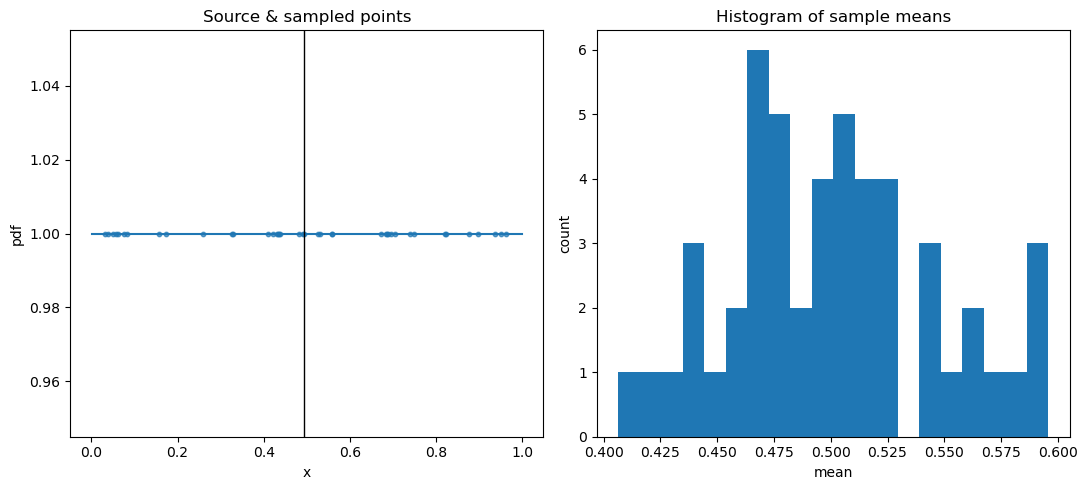

In [42]:
visualize_clt("uniform", x1=40, x2=50, pause_s=0.3,
                  dist_params={"loc":0, "scale":1},
                  capture_gif_path="clt.gif", capture_backend="mpl")